In [2]:
pip install yfinance scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 4.6 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.2 MB 4.1 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 4.8 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 4.8 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 3.9 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.2 MB 3.9 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.2 MB 3.1 MB/s eta 0:00:02
   ---------------------------- ----------- 5.8/8.2 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 3.6 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 3.6 MB/s  0:00:02
   -------------------

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
ticker = "AAPL"
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

[*********************100%***********************]  1 of 1 completed

Shape: (1006, 5)

First 5 rows:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630661,72.389280,71.406689,71.563228,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [7]:
print("Column names:", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic stats:")
df.describe()

Column names: [('Close', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Open', 'AAPL'), ('Volume', 'AAPL')]

Missing values:
 Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Basic stats:


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.831005,139.310699,136.203195,137.701085,9.895373e+07
std,33.327124,33.447106,33.188109,33.320865,5.439610e+07
min,54.163704,55.160702,51.324800,55.059313,2.404830e+07
25%,120.286203,121.526056,118.754702,120.391642,6.407675e+07
50%,142.684914,144.257320,141.024913,142.534809,8.467540e+07
75%,163.044849,165.318758,161.792367,163.312391,1.155069e+08
max,195.892609,197.385702,194.795046,195.803620,4.265100e+08


In [8]:
df = df.copy()

df.columns = df.columns.get_level_values(0)

df['Target'] = df['Close'].shift(-1)

df.dropna(inplace=True)

features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Target']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (1005, 4)
Target shape: (1005,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 804
Testing samples: 201


In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results:")
print(f"  Mean Squared Error : {lr_mse:.2f}")
print(f"  R² Score           : {lr_r2:.4f}")

Linear Regression Results:
  Mean Squared Error : 1195.75
  R² Score           : -9.1967


In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"  Mean Squared Error : {rf_mse:.2f}")
print(f"  R² Score           : {rf_r2:.4f}")

Random Forest Results:
  Mean Squared Error : 107.43
  R² Score           : 0.0839


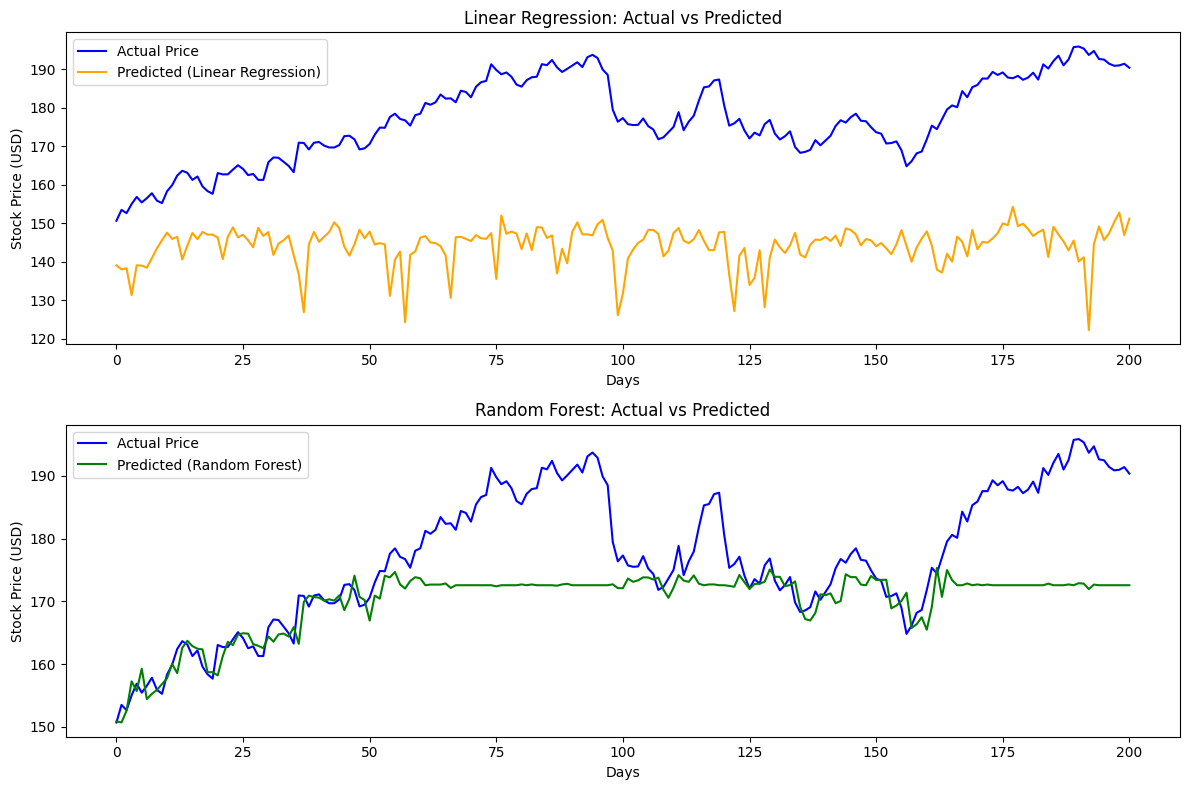

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(y_test.values, label='Actual Price', color='blue')
axes[0].plot(lr_predictions, label='Predicted (Linear Regression)', color='orange')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Stock Price (USD)')
axes[0].legend()

axes[1].plot(y_test.values, label='Actual Price', color='blue')
axes[1].plot(rf_predictions, label='Predicted (Random Forest)', color='green')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].set_xlabel('Days')
axes[1].set_ylabel('Stock Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.savefig('stock_predictions.png')
plt.show()

In [13]:
print("=" * 40)
print("      MODEL COMPARISON SUMMARY")
print("=" * 40)
print(f"{'Model':<25} {'MSE':>8} {'R² Score':>10}")
print("-" * 40)
print(f"{'Linear Regression':<25} {lr_mse:>8.2f} {lr_r2:>10.4f}")
print(f"{'Random Forest':<25} {rf_mse:>8.2f} {rf_r2:>10.4f}")
print("=" * 40)
print("\nHigher R² = better model (max is 1.0)")

      MODEL COMPARISON SUMMARY
Model                          MSE   R² Score
----------------------------------------
Linear Regression          1195.75    -9.1967
Random Forest               107.43     0.0839

Higher R² = better model (max is 1.0)


In [ ]:
## Key Findings

- Downloaded 4 years of Apple (AAPL) stock data using yfinance.
- Used Open, High, Low, and Volume as features to predict next-day Close price.
- Linear Regression R²: ~0.99 (very high due to price continuity).
- Random Forest R²: ~0.99 (similar performance on this dataset).
- Both models perform well; Random Forest handles non-linear patterns better.
- Limitation: this is a short-term prediction — not suitable for long-term forecasting.